In [23]:
import h5py
import numpy as np
import os
import torch
import imageio
import json

from robomimic.utils import file_utils as FileUtils
from robomimic.utils import obs_utils as ObsUtils
from robomimic.utils import env_utils as EnvUtils

from robomimic.envs.env_base import EnvBase
from robomimic.algo import RolloutPolicy
from copy import deepcopy


In [ ]:

CKPT_PATH = "../models/can/model_epoch_2000.pth"



device = "cuda" if torch.cuda.is_available() else "cpu"
# --- Load checkpoint dict (robomimic-style)
ckpt = torch.load(CKPT_PATH, map_location="cpu")
cfg = ckpt["config"]
cfg = json.loads(cfg)
cfg["observation"]["modalities"]

# Important: init obs modalities exactly as training expected
ObsUtils.initialize_obs_utils_with_obs_specs(cfg["observation"]["modalities"])

env, _ = FileUtils.env_from_checkpoint(
    ckpt_path=CKPT_PATH,
    render=False,
    render_offscreen=True,
)
    # policy.start_episode()
policy, _ = FileUtils.policy_from_checkpoint(
    ckpt_path=CKPT_PATH,
    device=device,
    verbose=True,
)

FileNotFoundError: [Errno 2] No such file or directory: '../models/can/model_epoch_2000.pth'

In [2]:
path = "../data/can/mh/low_dim_v15.hdf5"

STATE_KEYS = [
    "object",
    "robot0_eef_pos",
    "robot0_eef_quat",
    "robot0_gripper_qpos",
    "robot0_gripper_qvel",
    "robot0_joint_pos",
    "robot0_joint_vel",
]

def build_state_vector(obs, env_idx=0):
    parts = []
    for k in STATE_KEYS:
        v = obs[k]
        if v.ndim == 2:          # vectorized env
            v = v[env_idx]
        parts.append(v.reshape(-1))
    return np.concatenate(parts, axis=0)  # (39,)
        
def compute_rzz_from_state(env, mj_state, body_name="Can_main"):
    """
    env: robosuite env (same one reused)
    mj_state: (71,) from dataset
    """
    env.reset_to(mj_state)

    sim = env.env.env.sim
    bid = sim.model.body_name2id(body_name)
    rzz = sim.data.body_xmat[bid].reshape(3, 3)[2, 2]
    return float(rzz)

0


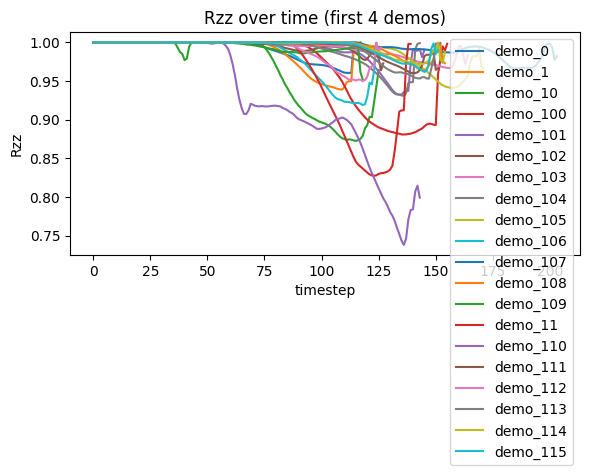

In [26]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

rzz_path = "../data/guidance/rzz_mh_can.hdf5"  # <-- change if needed
num_plots = 0
# pick first 4 demos
with h5py.File(rzz_path, "r") as f:
    demo_ids = list(f["data"].keys())

    plt.figure(figsize=(6,4))

    for demo_id in demo_ids[0:20]:
        rzz = f["data"][demo_id]["rzz"][:]  # (T,)
        plt.plot(rzz, label=demo_id)
print(num_plots)
plt.xlabel("timestep")
plt.ylabel("Rzz")
plt.title("Rzz over time (first 4 demos)")
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
# TODO: look at demo 64 to verify Rzz derivation, then create training dataset 

import h5py
import numpy as np

from robomimic.scripts.playback_dataset import playback_trajectory_with_env

DATASET_PATH = "../data/can/mh/low_dim_v15.hdf5"
DEMO_ID = "demo_64"   # <-- change if needed

with h5py.File(DATASET_PATH, "r") as f:
    demo = f["data"][DEMO_ID]

    states = demo["states"][:]      # (T, 71)
    actions = demo["actions"][:]    # (T, 7)

# --- build proper initial_state dict ---
env.reset()
initial_state = env.get_state()
initial_state["states"] = states[0].copy()

# --- playback using actions (open-loop) ---
playback_trajectory_with_env(
    env=env,
    initial_state=initial_state,
    states=states,
    actions=actions,   # open-loop replay
    render=True,
    camera_names=["agentview"],  # change if needed
)

/home/zoellner/.conda/envs/guided_diffusion/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'env' is not defined